# PJM East (PJME) Hourly Load Forecasting

Short experiment log: predicting hourly electricity load for the PJM East zone
from calendar features and lagged load, comparing a linear baseline against
gradient boosting.

- **Data:** `PJME_hourly.csv` — hourly load in MW, 2002-01 to 2018-08 (PJM Hourly Energy Consumption, Kaggle)
- **Target:** `PJME_MW`
- **Split:** chronological, train `< 2015-01-01`, test `>= 2015-01-01`
- **Models:** `LinearRegression` (baseline) vs `XGBRegressor`
- **Metrics:** RMSE (MW) and MAPE (%)

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# By default the CSV is expected next to this notebook.
# Set the PJME_CSV environment variable to point somewhere else.
DATA_PATH = os.environ.get("PJME_CSV", "PJME_hourly.csv")

In [3]:
# parse_dates turns the Datetime column into real timestamps; index_col=0 makes it the index
df = pd.read_csv(DATA_PATH, parse_dates=["Datetime"], index_col=[0])
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [4]:
df.dtypes  # Datetime is now a proper datetime index; MW = megawatts

PJME_MW    float64
dtype: object

## 2. Feature engineering

Three groups of features:

1. **Calendar** — month, day of week, hour. Load has a strong daily and weekly cycle.
2. **Holiday flag** — US federal holidays, since load drops on those days.
3. **Lags** — load 24h ago and 168h (one week) ago, the two most obvious autoregressive signals.

The raw CSV is not sorted by time, so `sort_index()` has to come first — otherwise
`shift()` would build lags out of neighbouring rows that are not actually adjacent in time.

In [5]:
# pip install holidays
import holidays

In [6]:
# The raw file is not in chronological order. Sort before anything time-dependent.
df = df.sort_index()

us_holidays = holidays.US()

# the holidays library matches on date objects, not timestamps
df["is_holidays"] = df.index.date
df["is_holidays"] = df["is_holidays"].apply(lambda x: 1 if x in us_holidays else 0)

# Calendar features
df["Month"] = df.index.month
df["Week"] = df.index.dayofweek
df["Hour"] = df.index.hour

# Lag features: same hour yesterday, and same hour one week ago
df["Lags_24hrs"] = df["PJME_MW"].shift(24)
df["Lags_168hrs"] = df["PJME_MW"].shift(168)

# scikit-learn does not accept NaN, and the first 168 rows have no lag values
df = df.dropna()

In [7]:
df.tail(10)  # sanity check

,PJME_MW,is_holidays,Month,Week,Hour,Lags_24hrs,Lags_168hrs
Datetime,,,,,,,
2018-08-02 15:00:00,47154.0,0,8,3,15,46430.0,45954.0
2018-08-02 16:00:00,46989.0,0,8,3,16,47867.0,47369.0
2018-08-02 17:00:00,46816.0,0,8,3,17,48855.0,48525.0
2018-08-02 18:00:00,46760.0,0,8,3,18,49308.0,49029.0
2018-08-02 19:00:00,45641.0,0,8,3,19,48428.0,48261.0
2018-08-02 20:00:00,44057.0,0,8,3,20,46912.0,46337.0
2018-08-02 21:00:00,43256.0,0,8,3,21,45985.0,44542.0
2018-08-02 22:00:00,41552.0,0,8,3,22,44094.0,42638.0
2018-08-02 23:00:00,38500.0,0,8,3,23,40666.0,39276.0


## 3. Train / test split

Time series, so the split is chronological — never random. Everything before 2015
trains the model, everything from 2015 onward is held out.

In [8]:
train = df.loc[df.index < "2015-01-01"].copy()
test = df.loc[df.index >= "2015-01-01"].copy()

Features = ["is_holidays", "Month", "Week", "Hour", "Lags_24hrs", "Lags_168hrs"]
Target = ["PJME_MW"]

X_train, y_train = train[Features], train[Target]
X_test, y_test = test[Features], test[Target]

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (113758, 6), test: (31440, 6)


## 4. Baseline — Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
test["prediction"] = model.predict(X_test)
y_pred = test["prediction"]

In [11]:
# Flatten both sides to 1-D before the elementwise division, otherwise a (n, 1)
# array minus a (n,) array broadcasts into an (n, n) matrix and MAPE is meaningless.
y_true = y_test.values.ravel()

lr_rmse = np.sqrt(mean_squared_error(y_true, y_pred.values))
lr_mape = np.mean(np.abs(y_true - y_pred.values) / y_true) * 100

print(f"LinearRegression RMSE: {lr_rmse:.2f}")
print(f"LinearRegression MAPE: {lr_mape:.2f}%")

LinearRegression RMSE: 2624.68
LinearRegression MAPE: 6.25%


## 5. XGBoost

Same features, same split — the only thing that changes is the model, so any
difference in the metrics is attributable to the model itself.

In [12]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)  # XGBoost returns a 1-D array, shape (n,)

In [13]:
xgb_rmse = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
xgb_mape = np.mean(np.abs(y_true - y_pred_xgb) / y_true) * 100

print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost MAPE: {xgb_mape:.2f}%")

XGBoost RMSE: 2445.27
XGBoost MAPE: 5.64%


## 6. Diagnostics

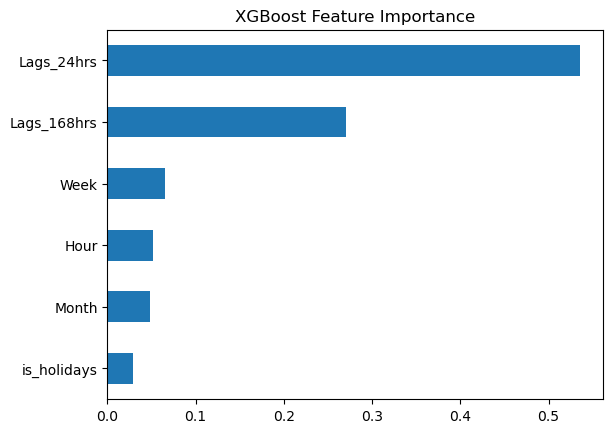

is_holidays    0.028511
Month          0.048524
Hour           0.051816
Week           0.065248
Lags_168hrs    0.270639
Lags_24hrs     0.535261
dtype: float32


In [14]:
# Which features is the model actually using?
importance = pd.Series(xgb_model.feature_importances_, index=Features)
importance = importance.sort_values(ascending=True)

importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.show()
print(importance)

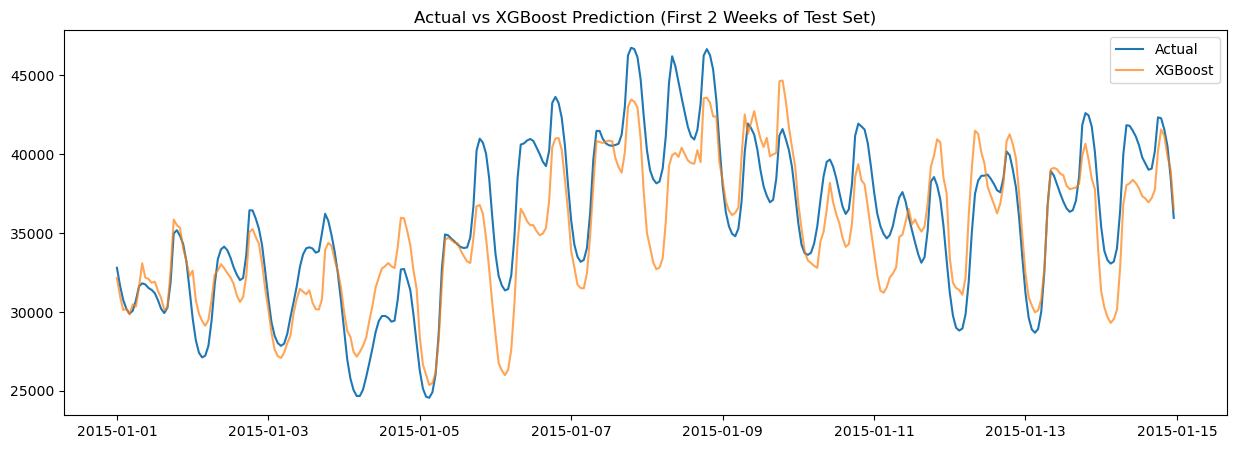

In [15]:
# Zoom in on the first two weeks of the test set to see where the error actually is
plot_df = test.iloc[: 24 * 14].copy()
plot_df["xgb_pred"] = y_pred_xgb[: 24 * 14]

plt.figure(figsize=(15, 5))
plt.plot(plot_df.index, plot_df["PJME_MW"], label="Actual")
plt.plot(plot_df.index, plot_df["xgb_pred"], label="XGBoost", alpha=0.7)
plt.title("Actual vs XGBoost Prediction (First 2 Weeks of Test Set)")
plt.legend()
plt.show()

### Reading the plot

**The cycles are learned; the extremes are not.** The prediction follows the daily
and weekly shape closely, but it is visibly flatter than the actual series — it
does not reach the peaks and does not fall to the troughs.

The residual diagnostics below quantify that. Splitting the test set into deciles
of actual load, the bias is close to monotone:

| Load level | Mean actual (MW) | Mean bias (MW) |
|---|---|---|
| Lowest decile | 22,040 | **+825** (over-predicts) |
| Middle | 30,966 | +691 |
| Highest decile | 44,605 | **−1,745** (under-predicts) |

This is regression toward the mean, and it is what a lag-driven model does: with
`Lags_24hrs` and `Lags_168hrs` carrying 80.6% of the total gain, the prediction is
anchored to recent load and cannot commit to a value far from it. The peak decile
is under-predicted by 3.9% on average — the operationally expensive direction of
error, since peak load is what capacity has to cover.

**A daytime over-prediction bias.** Mean residual across the whole test set is
+225 MW. Broken out by hour, it is small overnight (54-111 MW between 00:00 and
06:00) and largest in the early afternoon (375 MW at 14:00). The model runs
systematically high during working hours.

**Holidays are still weak.** MAPE on federal holidays is 6.34% against 5.62% on
normal days — 13% relatively worse. The `is_holidays` flag helps, but it only
tells the model *that* a day is a holiday, not that the holiday load *curve has a
different shape*. A single binary column cannot express that, which is why it
carries the least gain of any feature (0.029).

**In one line:** the model has learned the periodic structure and reached 5.6%
MAPE without any weather input, but it compresses the range — under-predicting
peaks and over-predicting troughs — and it treats holidays as ordinary days with
a flag attached. Temperature features and an hour-of-day holiday profile address
those two failures directly.

In [16]:
# sanity checks
print(test.shape)
print(test.index[:5])
print(len(y_pred_xgb))
print("test index sorted:", test.index.is_monotonic_increasing)
print("full index sorted:", df.index.is_monotonic_increasing)

(31440, 8)
DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)
31440
test index sorted: True
full index sorted: True


## 7. Results

In [17]:
summary = pd.DataFrame(
    {
        "Model": ["LinearRegression", "XGBoost"],
        "RMSE (MW)": [round(lr_rmse, 2), round(xgb_rmse, 2)],
        "MAPE (%)": [round(lr_mape, 2), round(xgb_mape, 2)],
    }
)

print(summary.to_string(index=False))

           Model  RMSE (MW)  MAPE (%)
LinearRegression    2624.68      6.25
         XGBoost    2445.27      5.64


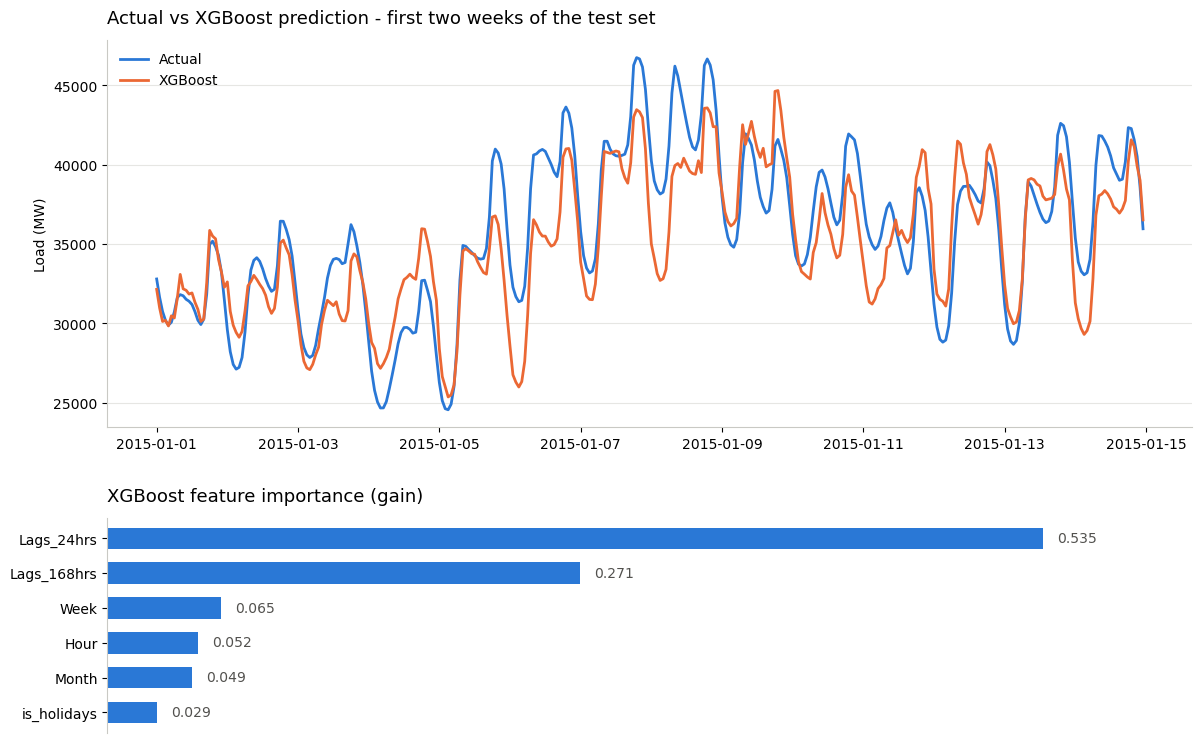

In [18]:
# One combined figure for the README.
# The time series gets the full width - squeezing 336 hourly points into a half
# panel destroys exactly the detail the plot exists to show.
os.makedirs("figures", exist_ok=True)

ACTUAL, PRED = "#2a78d6", "#eb6834"

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[1.8, 1], hspace=0.30)

ax1 = fig.add_subplot(gs[0])
ax1.plot(plot_df.index, plot_df["PJME_MW"], label="Actual", color=ACTUAL, linewidth=2)
ax1.plot(plot_df.index, plot_df["xgb_pred"], label="XGBoost", color=PRED, linewidth=2)
ax1.set_title("Actual vs XGBoost prediction - first two weeks of the test set",
              fontsize=13, pad=12, loc="left")
ax1.set_ylabel("Load (MW)")
ax1.legend(frameon=False, loc="upper left")
ax1.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax1.set_axisbelow(True)
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax1.spines[side].set_color("#c9c9c4")

ax2 = fig.add_subplot(gs[1])
ax2.barh(importance.index, importance.values, color=ACTUAL, height=0.62)
ax2.set_title("XGBoost feature importance (gain)", fontsize=13, pad=12, loc="left")
ax2.set_xlim(0, importance.max() * 1.16)
for name, val in importance.items():
    ax2.text(val + importance.max() * 0.015, name, f"{val:.3f}",
             va="center", fontsize=10, color="#52514e")
# the bars carry direct value labels, so the x axis is redundant
ax2.set_xticks([])
for side in ("top", "right", "bottom"):
    ax2.spines[side].set_visible(False)
ax2.spines["left"].set_color("#c9c9c4")

fig.savefig("figures/results.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [19]:
# Where does the error actually live? Bias by load level and by hour of day.
resid = y_pred_xgb - y_true  # positive = over-prediction

level = pd.qcut(y_true, 10, labels=False)
by_level = pd.DataFrame({"actual": y_true, "resid": resid, "decile": level})
level_bias = by_level.groupby("decile").agg(
    mean_actual=("actual", "mean"), mean_bias=("resid", "mean")
)

hour_bias = pd.DataFrame({"hour": test["Hour"].values, "resid": resid}).groupby("hour")["resid"].mean()

holiday_mask = test["is_holidays"].values == 1
holiday_mape = np.mean(np.abs(resid[holiday_mask]) / y_true[holiday_mask]) * 100
normal_mape = np.mean(np.abs(resid[~holiday_mask]) / y_true[~holiday_mask]) * 100

print("Bias by load decile (positive = over-prediction):")
print(level_bias.round(1).to_string())
print()
print(f"MAPE on holidays: {holiday_mape:.2f}%  |  on normal days: {normal_mape:.2f}%")

Bias by load decile (positive = over-prediction):
        mean_actual  mean_bias
decile                        
0           22040.5      825.2
1           24851.6      761.2
2           26849.3      752.8
3           28403.6      825.5
4           29599.7      816.5
5           30966.3      691.3
6           32699.8      127.2
7           35008.5     -173.4
8           38208.0     -628.8
9           44604.6    -1745.3

MAPE on holidays: 6.34%  |  on normal days: 5.62%


In [20]:
# Dump the headline numbers so they can be picked up outside the notebook
import json

results = {
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "linear_regression": {"rmse": float(lr_rmse), "mape": float(lr_mape)},
    "xgboost": {"rmse": float(xgb_rmse), "mape": float(xgb_mape)},
    "feature_importance": {k: float(v) for k, v in importance.items()},
    "xgboost_params": xgb_model.get_params(),
    "bias_by_decile": level_bias.round(2).to_dict(orient="index"),
    "bias_by_hour": {int(k): round(float(v), 2) for k, v in hour_bias.items()},
    "holiday_mape": float(holiday_mape),
    "normal_day_mape": float(normal_mape),
    "resid_mean": float(resid.mean()),
    "peak_decile_bias": float(level_bias["mean_bias"].iloc[-1]),
    "trough_decile_bias": float(level_bias["mean_bias"].iloc[0]),
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)

# keep the plotted window so the figure can be re-styled without refitting
plot_df[["PJME_MW", "xgb_pred"]].to_csv("plot_data.csv")

print(json.dumps({k: results[k] for k in ("n_train", "n_test", "linear_regression", "xgboost")}, indent=2))

{
  "n_train": 113758,
  "n_test": 31440,
  "linear_regression": {
    "rmse": 2624.683512638481,
    "mape": 6.253915893326307
  },
  "xgboost": {
    "rmse": 2445.26691336244,
    "mape": 5.638320430120595
  }
}


## 8. Roadmap

Notes carried over from the follow-up notebook — what would actually make this
project stronger, roughly in order:

- **Weather features.** Temperature (and humidity / heating- and cooling-degree days)
  is the single biggest missing driver. The Jan 9 overshoot above is a weather event
  the model had no way to see.
- **Holiday load shape**, not just a holiday flag — an hour-of-day profile that differs
  on holidays, rather than one binary column.
- **Engineering comparison over metric-chasing.** When running two models side by side,
  the interesting comparison is training time, memory, whether the feature-importance
  rankings agree, and how sensitive each is to hyperparameters. That is more informative
  than "the ensemble improved RMSE by 0.5%".
- **Error analysis by time segment** — MAPE broken out by hour of day, by season, and by
  weekday vs weekend, to find *where* the model fails rather than only *how much*.
- **Probabilistic forecasting** — quantile regression to output prediction intervals
  instead of a single point forecast. Closer to how forecasts are actually consumed.
- **Adjacent problems** worth building next: solar power forecasting with NWP (numerical
  weather prediction) inputs, which is closer to a real operational setup; or electricity
  price forecasting, where the heavy-tailed distribution makes the choice of loss
  function a real decision.